In [20]:
# PINN Black-Scholes

In [21]:
# Standard library imports
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

### Paths

In [22]:
# Pathways 
data_path = Path("..") / "data" / "generated" / "bs_collocation.parquet"
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path_pinn = out_dir / "pinn_bs.pdf"
out_path_loss_total = out_path = out_dir / "pinn_bs_loss_total.pdf"
out_path_loss_pde = out_path = out_dir / "pinn_bs_loss_pde.pdf"
out_path_loss_ic = out_path = out_dir / "pinn_bs_loss_ic.pdf"
out_path_loss_bc = out_path = out_dir / "pinn_bs_loss_bc.pdf"

### Global parameters

In [23]:
# Answer to the universe and everything
torch.manual_seed(42)

# Option Physics (Analytical Benchmarks)
K = 100.0
r = 0.05
sigma = 0.20
T_max = 1.0
S_max = 300.0

# NN
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 128

# Training
LEARNING_RATE = 0.0005
EPOCHS = 5000
PRINT_ROWS = 20

# PINN Loss Weights
LAMBDA_PDE = 5.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0

### Black-Scholes PINN Class

In [24]:
class BSPINN(nn.Module):
    def __init__(self, hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER):
        super(BSPINN, self).__init__()

        # Input layer: Takes (S, tau) -> 2 dimensions
        layers = [nn.Linear(2, neurons_per_layer), nn.Softplus()]

        # Hidden layers
        # Softplus or Tanh here since ReLU has a 2nd derivative of 0,
        # which would make V_SS completely vanish in our PDE
        for _ in range(hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.Softplus())

        # Outer layer: Returns V (Option Price) -> 1 dimension
        layers.append(nn.Linear(neurons_per_layer, 1))

        self.net = nn.Sequential(*layers)
    
    def forward(self, S, tau):
        # concatenate S and tau into a single input tensor
        x = torch.cat([S, tau], dim=1)
        return self.net(x)


### Reading data

In [25]:
# Loading Parquet data file into a Pandas DataFrame
df_all = pd.read_parquet(data_path)

# Helper function to extract columns and turn them into gradient-tracking Tensors
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    return S_tensor, tau_tensor

# Interior points
df_interior = df_all[df_all['point_type'] == 'interior']
S_in, tau_in = extract_tensors(df_interior)

# Initial Condition points (Maturity)
df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, tau_ic = extract_tensors(df_ic)

# Boundary Condition points (S = 0)
df_bc = df_all[df_all['point_type'] == 'boundary_condition']
S_bc, tau_bc = extract_tensors(df_bc)

print(f"Read data from {data_path}")
print(f"Interior points: {len(S_in)}")
print(f"IC points: {len(S_ic)}")
print(f"BC points: {len(S_bc)}")

Read data from ..\data\generated\bs_collocation.parquet
Interior points: 2000
IC points: 500
BC points: 500


### Training a PINN

In [26]:
# Initiate the PINN and the Optimizer
model = BSPINN(hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER)

# Adam is the standard workhorse optimiser for Deep Learning
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Training Loop

In [27]:
# Inputs
epochs = EPOCHS
print(f"Starting PINN learning at {epochs} epochs")

Starting PINN learning at 5000 epochs


In [28]:
# Initialize history lists
history = {
    'epoch': [],
    'total': [],
    'pde': [],
    'ic': [],
    'bc': []
}

# Print the table header
print(f"{'Epoch':>6} | {'Total Loss':>12} | {'PDE Loss':>12} | {'IC Loss':>12} | {'BC Loss':>12}")
print("-" * 66)

# Creating an array **once** before the loop starts
# to stop memory thrashing
grad_ones = torch.ones_like(S_in)

# Start that timer!
start_time = time.time()

# Looping over the epochs
for epoch in range(epochs):

    # Always zero the gradient before a new step
    optimizer.zero_grad()

    # Calculating the PDE loss
    V_pred = model(S_in, tau_in)

    # Automatic differentiation for the gradients using the pre-allocated array!
    V_S = torch.autograd.grad(V_pred, S_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_tau = torch.autograd.grad(V_pred, tau_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S_in, grad_outputs=grad_ones, create_graph=True)[0]

    # Black-Scholes PDE equation
    pde_residual = V_tau - (0.5 * sigma**2 * S_in**2 * V_SS + r * S_in * V_S - r * V_pred)
    loss_pde = torch.mean(pde_residual**2)

    # Calculating the initial condition loss
    # which is the payoff at maturity
    V_ic_pred = model(S_ic, tau_ic)

    # True payoff of a Call option is maX(S-K, 0)
    V_ic_true = torch.relu(S_ic - K)
    loss_ic = torch.mean((V_ic_pred - V_ic_true)**2)

    # Calculating the boundary condition loss at S=0
    V_bc_pred = model(S_bc, tau_bc)

    # A call option is worth 0 if the stock price is 0
    loss_bc = torch.mean((V_bc_pred - 0.0)**2)

    # Total Loss and Backpropagation
    loss = (LAMBDA_PDE * loss_pde) + (LAMBDA_IC * loss_ic) + (LAMBDA_BC * loss_bc)

    # Compute the gradients and update the neural 
    # network weights
    loss.backward()
    optimizer.step()

    # Record history for plotting
    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['bc'].append(loss_bc.item())

    # Print 20 rows of progress
    print_interval = max(1, epochs // PRINT_ROWS)
    if epoch % print_interval == 0:
        print(f"{epoch:6d} | {loss.item():12.6f} | {loss_pde.item():12.6f} | {loss_ic.item():12.6f} | {loss_bc.item():12.6f}")

# Stop that timer!
end_time = time.time()

# Calculate minutes and seconds
total_seconds = end_time - start_time
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

# Calculate dataset metrics
n_interior = len(S_in)
n_ic = len(S_ic)
n_bc = len(S_bc)
total_points = n_interior + n_ic + n_bc

# Printout training complete with the final metrics
print("-" * 66)
print(f"Training Complete! Trained {epochs} epochs in {minutes} minutes and {seconds} seconds.")
print(f"Dataset Size: {total_points:,} total points ({n_interior:,} Interior, {n_ic:,} IC, {n_bc:,} BC)")
print(f"Final Total Loss: {loss.item():.6f}")
print("=" * 66)


 Epoch |   Total Loss |     PDE Loss |      IC Loss |      BC Loss
------------------------------------------------------------------
     0 |  1971.864990 |     0.000150 |   197.173370 |     0.026112


   250 |   123.342049 |     0.482105 |    12.088337 |     0.009630
   500 |    98.119698 |     1.125233 |     9.235518 |     0.027671
   750 |    11.640895 |     0.876582 |     0.725623 |     0.000351
  1000 |    26.667370 |     0.491386 |     2.415254 |     0.011581
  1250 |    59.197243 |     0.273421 |     5.778577 |     0.008873
  1500 |     7.361033 |     0.545288 |     0.463227 |     0.000464
  1750 |     6.200141 |     0.502103 |     0.368587 |     0.000750
  2000 |    68.559998 |     0.429423 |     6.640893 |     0.000791
  2250 |     5.803655 |     0.450761 |     0.354557 |     0.000857
  2500 |     5.907316 |     0.488659 |     0.346038 |     0.000728
  2750 |     4.858436 |     0.421072 |     0.275221 |     0.000174
  3000 |    64.732712 |     0.360044 |     6.293218 |     0.000064
  3250 |     4.473713 |     0.388232 |     0.253134 |     0.000242
  3500 |     7.577793 |     0.362790 |     0.575636 |     0.001498
  3750 |     4.357843 |     0.309291 |     0.279791 |     0.00

### Pre-plotting

In [29]:
# Running another notebook including the analytical Black-Scholes
%run bs.ipynb

In [30]:
# Creating a clean 50x50 grid for plotting
S_plot = np.linspace(1e-5, S_max, 50)
tau_plot = np.linspace(0.01, T_max, 50)
S_grid, tau_grid = np.meshgrid(S_plot, tau_plot)

# Flatten the grids and convert to PyTorch
# tensors from the model
S_flat = torch.tensor(S_grid.flatten(), dtype=torch.float32).view(-1, 1)
tau_flat = torch.tensor(tau_grid.flatten(), dtype=torch.float32).view(-1, 1)

# Getting PINN predictions
# using torch.no_grad() because we are done training
# and dont need to track derivatives anymore
with torch.no_grad():
    V_pred_flat = model(S_flat, tau_flat).numpy()

# Reshape the flat predictions back into the 50x50
pinn_surface = V_pred_flat.reshape(S_grid.shape)

# Calculating true analyical prices
# assuming the bs function from earlier still
# in memory, passing tau_grid as T 
analytical_surface = bs(S=S_grid, K=K, T=tau_grid, r=r, sigma=sigma, type="call")

### Plotting the 3d surfaces

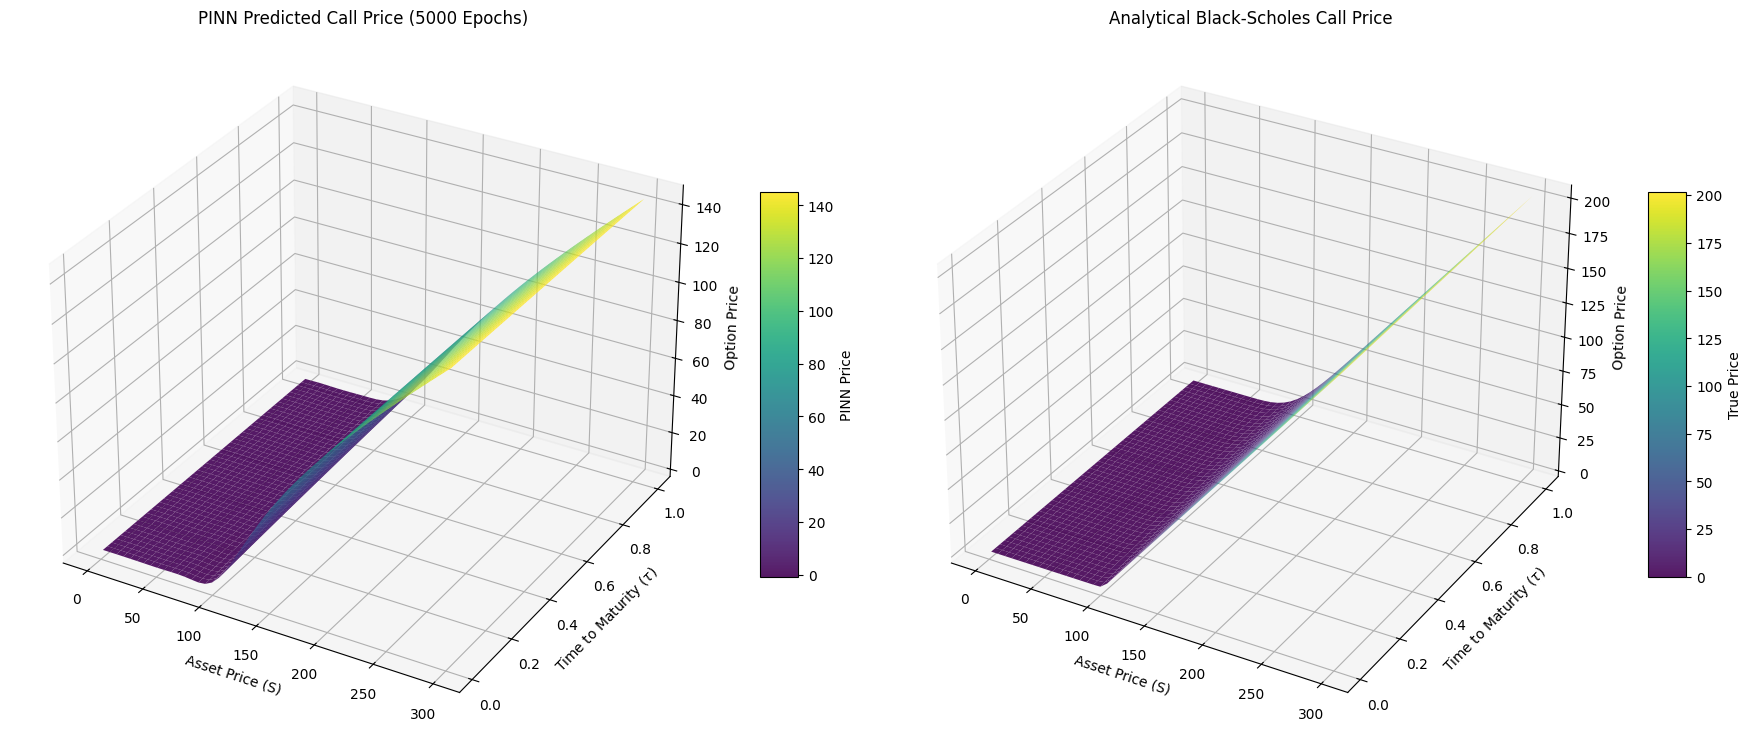

In [31]:
# Setting up the figure
fig = plt.figure(figsize=(18, 8))

# Left plot: PINN prediction
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(S_grid, tau_grid, pinn_surface, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax1.set_title(f'PINN Predicted Call Price ({epochs} Epochs)')
ax1.set_xlabel('Asset Price (S)')
ax1.set_ylabel('Time to Maturity ($\\tau$)')
ax1.set_zlabel('Option Price')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='PINN Price')

# Right plot: True math
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(S_grid, tau_grid, analytical_surface, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax2.set_title('Analytical Black-Scholes Call Price')
ax2.set_xlabel('Asset Price (S)')
ax2.set_ylabel('Time to Maturity ($\\tau$)')
ax2.set_zlabel('Option Price')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='True Price')

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_pinn, bbox_inches="tight")
plt.show()

### Plotting Total Loss

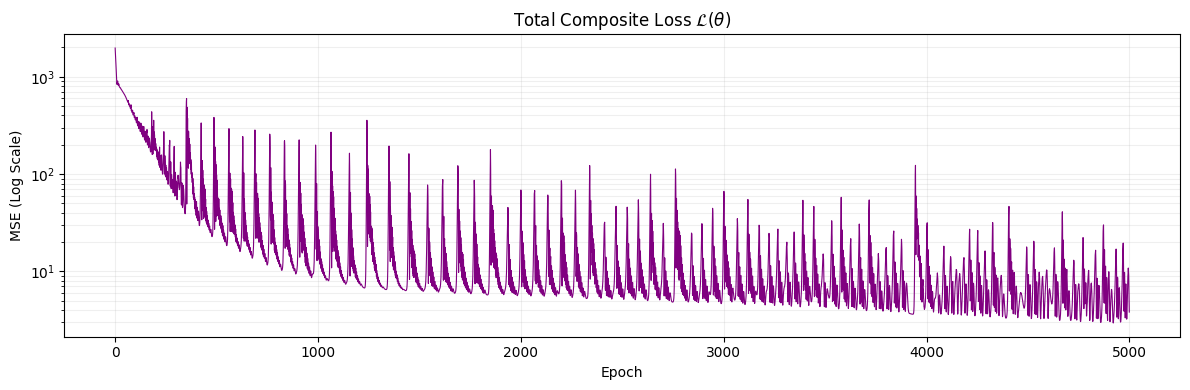

In [32]:
# Setting up figure 
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['total'], color='purple', lw=0.8)
plt.yscale('log')
plt.title('Total Composite Loss $\mathcal{L}(\\theta)$')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_total, bbox_inches="tight")
plt.show()

### Plotting PDE Loss

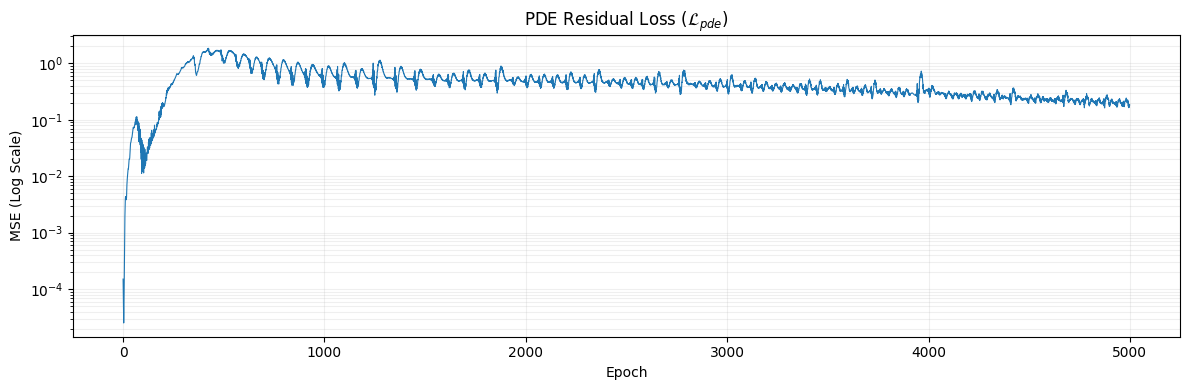

In [33]:
# Setting up the figure
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['pde'], color='tab:blue', lw=0.8)
plt.yscale('log')

# Title, axes titles, and grid
plt.title('PDE Residual Loss ($\mathcal{L}_{pde}$)')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_pde, bbox_inches="tight")
plt.show()

### Plotting Initial Condition Loss

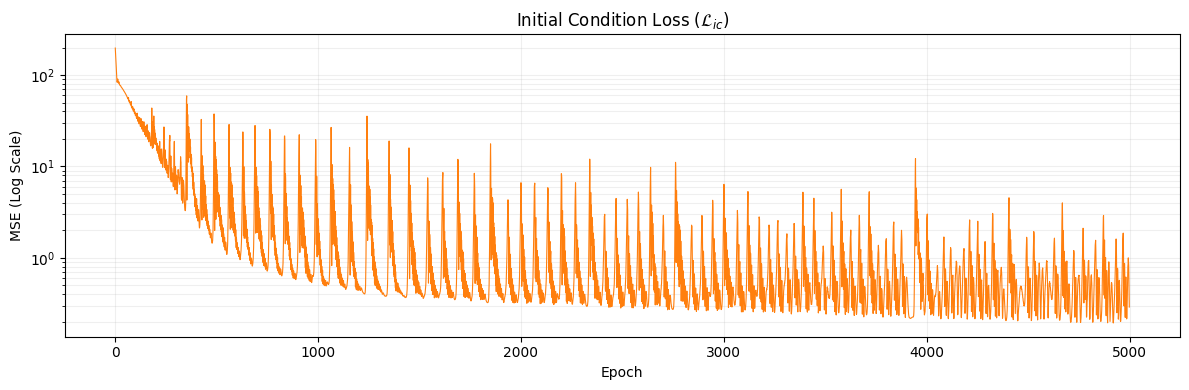

In [34]:
# Setting up the figure
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['ic'], color='tab:orange', lw=0.8)
plt.yscale('log')

# Title, axes titles, and grid
plt.title('Initial Condition Loss ($\mathcal{L}_{ic}$)')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_ic, bbox_inches="tight")
plt.show()

### Plotting Boundary Condition Loss

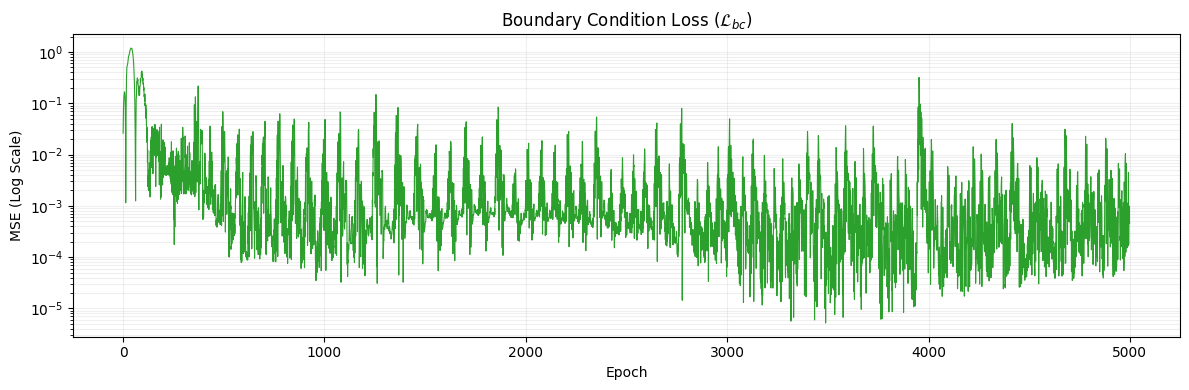

In [35]:
# Setting up the figure
plt.figure(figsize=(12, 4))
plt.plot(history['epoch'], history['bc'], color='tab:green', lw=0.8)
plt.yscale('log')

# Title, axes titles, and grid
plt.title('Boundary Condition Loss ($\mathcal{L}_{bc}$)')
plt.xlabel('Epoch')
plt.ylabel('MSE (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_loss_bc, bbox_inches="tight")
plt.show()

### Greeks

In [36]:
# Running the greeks notebook
%run greeks.ipynb

In [37]:
# Setting up a test point: At-the-Money (S=K) at 6 months (tau=0.5)
S_test = torch.tensor([[K]], requires_grad=True)
tau_test = torch.tensor([[0.5]], requires_grad=True)

# Compute all Greeks
greeks = compute_greeks(model, S_test, tau_test)

# Analytical truth for comparison
V_true = bs(K, K, 0.5, r, sigma)

### Printout

In [38]:
def fmt(val):
    return f"{val.item():12.6f}" if val is not None else "         N/A"

g = greeks

rows = [
    ("Price (V)",  "V(S,τ)",     "-",  fmt(g["V"])),
    ("Delta (Δ)",  "∂V/∂S",     "1st", fmt(g["Delta"])),
    ("Theta (Θ)",  "∂V/∂τ",     "1st", fmt(g["Theta"])),
    ("Rho (ρ)",    "∂V/∂r",     "1st", fmt(g["Rho"])),
    ("Phi (Φ)",    "∂V/∂q",     "1st", fmt(g["Phi"])),
    ("Vega",       "∂V/∂σ",     "1st", fmt(g["Vega"])),
    ("Gamma (Γ)",  "∂²V/∂S²",   "2nd", fmt(g["Gamma"])),
    ("Vomma",      "∂²V/∂σ²",   "2nd", fmt(g["Vomma"])),
    ("Vanna",      "∂²V/∂S∂σ",  "2nd", fmt(g["Vanna"])),
    ("Charm",      "∂²V/∂S∂τ",  "2nd", fmt(g["Charm"])),
    ("Speed",      "∂³V/∂S³",   "3rd", fmt(g["Speed"])),
    ("Zomma",      "∂³V/∂S²∂σ", "3rd", fmt(g["Zomma"])),
    ("Color",      "∂³V/∂S²∂τ", "3rd", fmt(g["Color"])),
]

print("\n" + "=" * 65)
print(f"{'GREEK':<12} | {'EXPRESSION':<16} | {'ORDER':<5} | {'PINN VALUE':>12}")
print("-" * 65)

for name, expr, order, val in rows:
    print(f"{name:<12} | {expr:<16} | {order:<5} | {val}")
print("-" * 65)

res = g["Theta"] - (0.5 * sigma**2 * S_test**2 * g["Gamma"] + r * S_test * g["Delta"] - r * g["V"])

print(f"{'PDE Residual':<12} | {'(Goal: 0.0)':<16} | {'':<5} | {res.item():12.6e}")
print("=" * 65)
print(f"\nAnalytical Price: {V_true:.6f}")


GREEK        | EXPRESSION       | ORDER |   PINN VALUE
-----------------------------------------------------------------
Price (V)    | V(S,τ)           | -     |     6.896077
Delta (Δ)    | ∂V/∂S            | 1st   |     0.621397
Theta (Θ)    | ∂V/∂τ            | 1st   |     8.163944
Rho (ρ)      | ∂V/∂r            | 1st   |          N/A
Phi (Φ)      | ∂V/∂q            | 1st   |          N/A
Vega         | ∂V/∂σ            | 1st   |          N/A
Gamma (Γ)    | ∂²V/∂S²          | 2nd   |     0.026552
Vomma        | ∂²V/∂σ²          | 2nd   |          N/A
Vanna        | ∂²V/∂S∂σ         | 2nd   |          N/A
Charm        | ∂²V/∂S∂τ         | 2nd   |     0.070291
Speed        | ∂³V/∂S³          | 3rd   |    -0.001066
Zomma        | ∂³V/∂S²∂σ        | 3rd   |          N/A
Color        | ∂³V/∂S²∂τ        | 3rd   |    -0.030265
-----------------------------------------------------------------
PDE Residual | (Goal: 0.0)      |       | 9.127998e-02

Analytical Price: 6.888729
